In [4]:
# pip install anndata scanpy pandas scipy numpy
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import anndata as ad
from pathlib import Path

def read_gem_to_adata(gem_path, sample=None):
    """
    Convert a STOmics GEM (tab-separated, gzipped) to an AnnData.
    Works with bin1.gem.gz and filtered_bin50.gem.gz.
    """
    gem_path = Path(gem_path)
    # GEMs are TSV; ignore any header lines starting with '#'
    df = pd.read_csv(gem_path, sep="\t", comment="#", compression="gzip")

    # Standardize column names across possible variants
    cols = {c.lower(): c for c in df.columns}
    # Expected: geneID, x, y, MIDCount|UMICount
    gene_col = cols.get("geneid", cols.get("gene", None))
    x_col    = cols.get("x")
    y_col    = cols.get("y")
    cnt_key = next(
    (k for k in ("midcounts","midcount","umicounts","umicount","counts","count")
     if k in cols),
    None
    )
    cnt_col = cols.get(cnt_key)
    if not all([gene_col, x_col, y_col, cnt_col]):
        raise ValueError(
            f"Unrecognized GEM columns. Found: {list(df.columns)}. "
            f"Looked for geneID/gene, x, y and a count column like MIDCounts/UMICounts."
        )

    if not all([gene_col, x_col, y_col, cnt_col]):
        raise ValueError(f"Unrecognized GEM columns: {df.columns.tolist()}")

    # Make spot ids from integer grid coordinates
    # (keeps them unique and easy to merge with annotation)
    x = df[x_col].astype(int)
    y = df[y_col].astype(int)
    spot_id = x.astype(str) + "x" + y.astype(str)

    genes = df[gene_col].astype("category")
    spots = spot_id.astype("category")

    # Build sparse matrix (spots × genes)
    data = df[cnt_col].astype(np.int64).to_numpy()
    row  = spots.cat.codes.to_numpy()
    col  = genes.cat.codes.to_numpy()
    X = coo_matrix((data, (row, col)),
                   shape=(spots.cat.categories.size, genes.cat.categories.size),
                   dtype=np.int32).tocsr()

    obs = pd.DataFrame(index=spots.cat.categories)
    # put spatial coords into same order as obs
    # extract the first occurrence of each (x,y) per spot
    # (category codes align with categories order)
    xy = pd.DataFrame({"spot_id": spot_id, "x": x, "y": y})
    xy = xy.drop_duplicates("spot_id").set_index("spot_id").loc[obs.index]
    obsm = {"spatial": xy[["x", "y"]].to_numpy()}

    var = pd.DataFrame(index=genes.cat.categories)
    adata = ad.AnnData(X=X, obs=obs, var=var, obsm=obsm)
    adata.obs[["x", "y"]] = xy[["x", "y"]].to_numpy()
    adata.uns["spatial_scale"] = "bins"  # no physical units available here
    if sample:
        adata.uns["sample"] = sample
        adata.obs["sample"] = sample
    return adata

def add_annotation_to_obs(adata, annotation_csv_gz, on=("x","y")):
    """
    Merge per-spot annotation (gzipped CSV) into adata.obs.
    Annotation is expected to have x,y columns on the same grid.
    """
    ann = pd.read_csv(annotation_csv_gz, compression="gzip")
    # Standardize column names to lower for matching; keep originals for values
    ann_cols = {c.lower(): c for c in ann.columns}
    xcol = ann_cols.get(on[0].lower(), on[0])
    ycol = ann_cols.get(on[1].lower(), on[1])
    ann = ann.rename(columns={xcol: "x", ycol: "y"})
    merged = adata.obs.reset_index(names="spot_id").merge(
        ann, on=["x", "y"], how="left"
    ).set_index("spot_id")
    adata.obs = merged
    return adata


In [2]:
data_path = Path("/g/stegle/aalsayah/repos/data/Stereo-Seq/STTS0000720")

In [5]:
# ---- Example usage with your three files ----
# (adjust the paths/filenames as needed)
bin50_path = Path(data_path /"Y-2M-Heart-1_1_filtered_bin50.gem.gz")
bin1_path  = Path(data_path / "Y-2M-Heart-1_1_bin1.gem.gz")
anno_path  = Path(data_path / "Y-2M-Heart-1_1_annotation.csv.gz")

# Build bin50 AnnData (recommended to start with; smaller and matches annotations)
adata50 = read_gem_to_adata(bin50_path, sample="Y-2M-Heart-1_1")
adata50 = add_annotation_to_obs(adata50, anno_path)
#adata50.write_h5ad("Y-2M-Heart-1_1_bin50.h5ad")

# (Optional) Build bin1 AnnData (very large)
# adata1 = read_gem_to_adata(bin1_path, sample="Y-2M-Heart-1_1")
# adata1 = add_annotation_to_obs(adata1, anno_path)  # will only work if annotation is at bin1 resolution
# adata1.write_h5ad("Y-2M-Heart-1_1_bin1.h5ad")


In [6]:
adata50

AnnData object with n_obs × n_vars = 35925 × 20778
    obs: 'x', 'y', 'sample', 'cellID', 'celltype'
    uns: 'spatial_scale', 'sample'
    obsm: 'spatial'

In [7]:
adata50.obs

,x,y,sample,cellID,celltype
spot_id,,,,,
100x100,100,100,Y-2M-Heart-1_1,BIN.27325,Cardiomyo-Ven
100x101,100,101,Y-2M-Heart-1_1,BIN.27600,Cardiomyo-Ven
100x103,100,103,Y-2M-Heart-1_1,BIN.28150,Cardiomyo-Ven
100x104,100,104,Y-2M-Heart-1_1,BIN.28425,Cardiomyo-Ven
100x105,100,105,Y-2M-Heart-1_1,BIN.28700,Cardiomyo-Ven
...,...,...,...,...,...
9x92,9,92,Y-2M-Heart-1_1,BIN.25034,Cardiomyo-Atr
9x93,9,93,Y-2M-Heart-1_1,BIN.25309,Cardiomyo-Atr
9x94,9,94,Y-2M-Heart-1_1,BIN.25584,Cardiomyo-Atr


In [9]:
import scanpy as sc

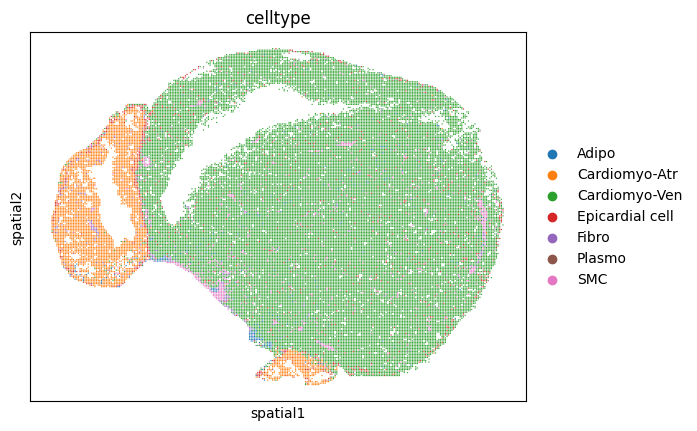

In [10]:
sc.pl.embedding(adata50, basis="spatial", color="celltype")